
# CSI-6-ARI Week 6 Tutorial - Complete Solution

## Supervised Learning (Classification) and Unsupervised Learning

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('gene_expression.csv')
print(df.head())
df = pd.read_csv('gene_expression.csv')print(df.shape, df['Cancer Present'].value_counts())

   Gene One  Gene Two  Cancer Present
0       4.3       3.9               1
1       2.5       6.3               0
2       5.7       3.9               1
3       6.1       6.2               0
4       7.4       3.4               1
(3000, 3) Cancer Present
1    1500
0    1500
Name: count, dtype: int64


In [5]:
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


In [6]:
df = pd.read_csv('gene_expression.csv')

In [4]:
from sklearn.model_selection import train_test_split

X = df[['Gene One', 'Gene Two']]
y = df['Cancer Present']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Set the default plot size for seaborn/matplotlib figures.

<Axes: xlabel='Gene One', ylabel='Gene Two'>

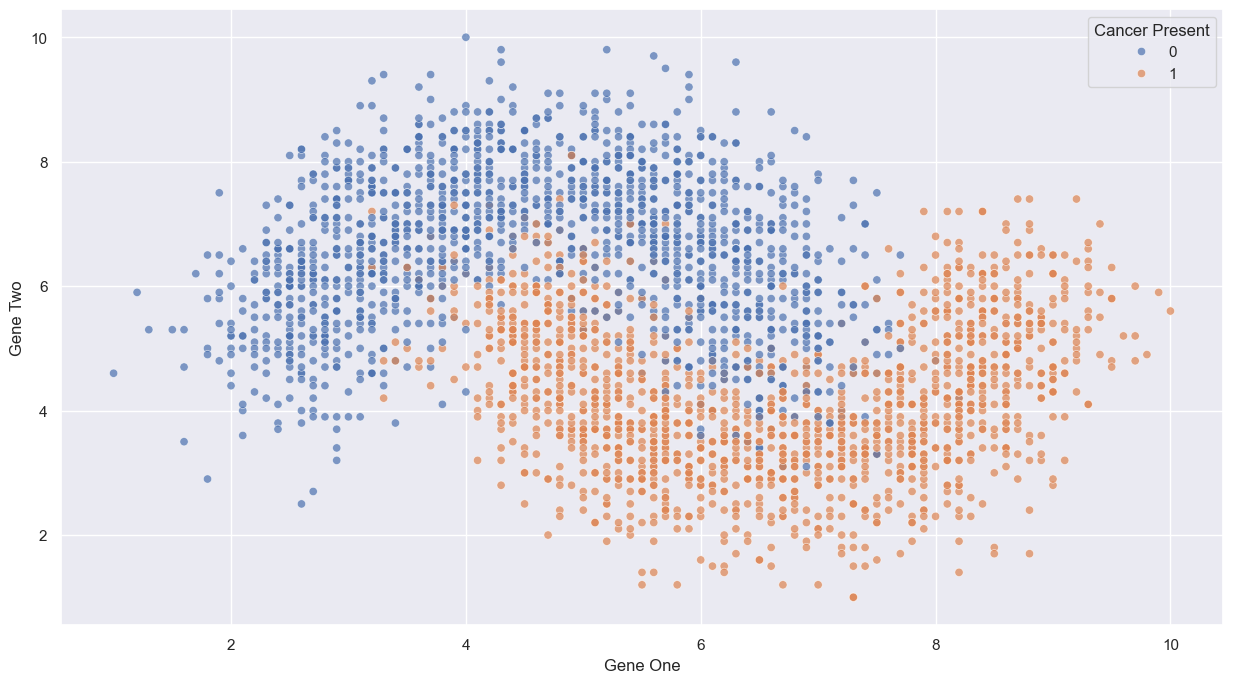

In [7]:
# Set the default plot size for seaborn/matplotlib figures.
# This makes the scatter plot easier to read (especially labels and class separation).
sns.set(rc={'figure.figsize': (15, 8)})

# Visualise the dataset in 2D using the two gene-expression features.
# Each point is one patient/sample, the colour (hue) shows the class label: whether cancer is present.
# alpha adds transparency so overlapping points are easier to see (reveals density).
sns.scatterplot(x='Gene One', y='Gene Two', hue='Cancer Present', data=df, alpha=0.7)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform on training data only — learns mean & std from train
X_train_scaled = scaler.fit_transform(X_train)

# transform only on test — uses the training mean & std
X_test_scaled  = scaler.transform(X_test)

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(X_train_scaled, y_train)
pred1 = knn1.predict(X_test_scaled)
print(accuracy_score(y_test, pred1))

0.8944444444444445


0.8944444444444445


Text(0, 0.5, 'Error Rate')

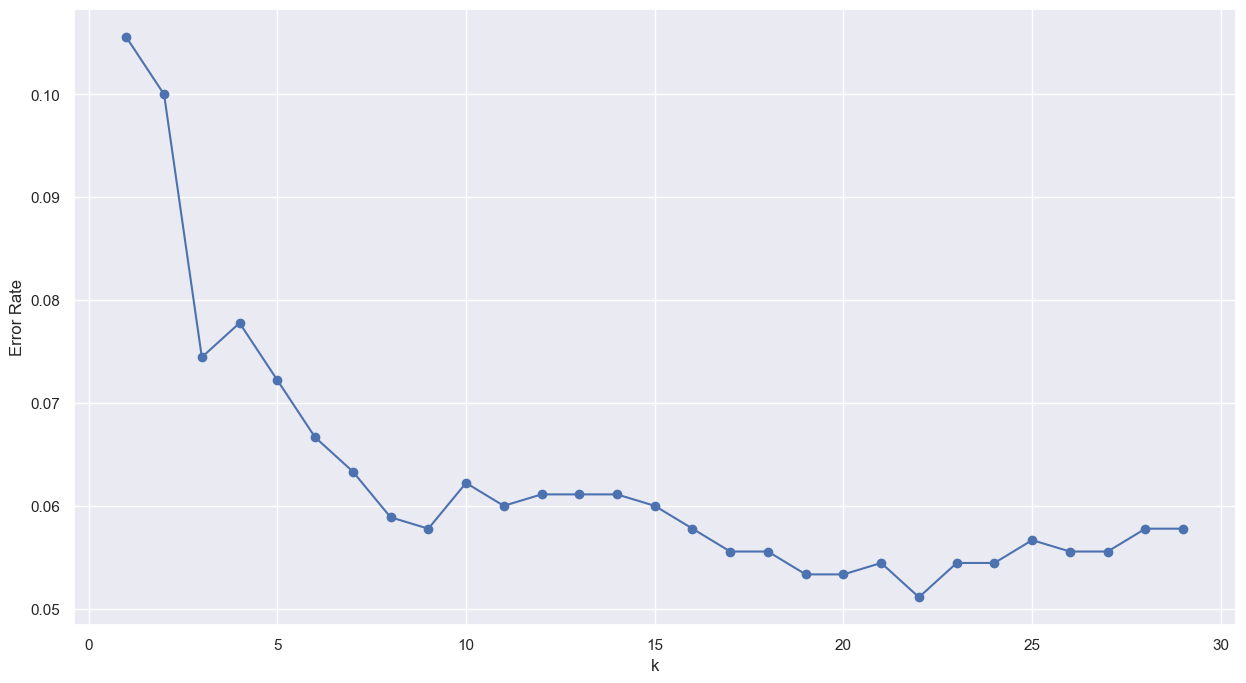

In [12]:
error_rates = []
for k in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    err = 1 - accuracy_score(y_test, knn.predict(X_test_scaled))
    error_rates.append(err)

plt.plot(range(1,30), error_rates, marker='o')
plt.xlabel('k'); plt.ylabel('Error Rate')

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# Pipeline: scaler then KNN
# Scaler fits only on each CV fold's training split — no leakage
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier())
])

param_grid = {'knn__n_neighbors': list(range(1, 30))}

full_cv = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
full_cv.fit(X_train, y_train)   # unscaled X_train — pipeline handles scaling

print(full_cv.best_params_, full_cv.best_score_)

{'knn__n_neighbors': 20} 0.9304761904761906
